# Exploratory Data Analysis on Loss Recovery in SP500

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.dpi'] = 110

In [2]:
CSV_PATH = "sp500_data.csv"
TICKER_LABEL = "S&P 500"
DRAWDOWN_THRESHOLD = -5.0  

df = pd.read_csv(CSV_PATH)
df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
df = df.sort_values('Date').reset_index(drop=True)
df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]

print(f"{TICKER_LABEL}: {len(df):,} trading days")
print(f"Range: {df['Date'].min().date()} -> {df['Date'].max().date()}")
df.head()

S&P 500: 8,565 trading days
Range: 1990-01-02 -> 2023-12-29


,Date,Open,High,Low,Close,Volume
0,1990-01-02 05:00:00,353.40,359.69,351.98,359.69,162070000
1,1990-01-03 05:00:00,359.69,360.59,357.89,358.76,192330000
2,1990-01-04 05:00:00,358.76,358.76,352.89,355.67,177000000
3,1990-01-05 05:00:00,355.67,355.67,351.35,352.20,158530000
4,1990-01-08 05:00:00,352.20,354.24,350.54,353.79,140110000


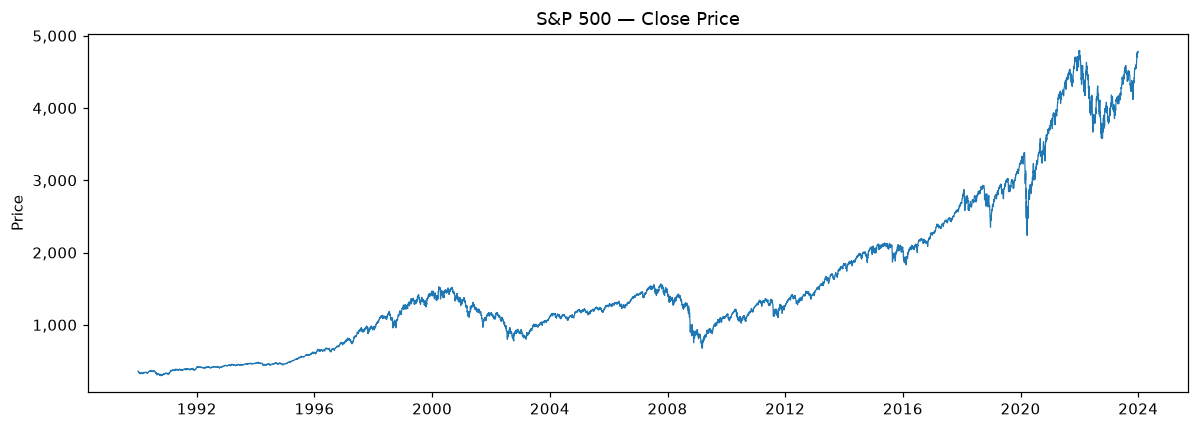

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df['Date'], df['Close'], lw=0.8, color='#1f77b4')
ax.set_title(f'{TICKER_LABEL} — Close Price')
ax.set_ylabel('Price')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

In [4]:
def detect_drawdown_episodes(dates, prices, threshold_pct):
    prices = np.asarray(prices, dtype=float)
    n = len(prices)

    running_max = prices[0]
    peak_price = prices[0]
    peak_date = dates[0]

    in_drawdown = False
    trough_price = np.inf
    trough_date = None

    episodes = []

    for i in range(1, n):
        p, d = prices[i], dates[i]

        if p >= running_max:
            if in_drawdown:
                loss_pct = (trough_price - peak_price) / peak_price * 100
                recovery_pct = (p - peak_price) / peak_price * 100  
                episodes.append({
                    'peak_date': peak_date, 'peak_price': peak_price,
                    'trough_date': trough_date, 'trough_price': trough_price,
                    'recovery_date': d, 'recovery_price': p,
                    'loss_pct': loss_pct, 'recovery_pct': recovery_pct,
                    'recovered': True,
                    'days_to_trough': int((trough_date - peak_date) / np.timedelta64(1, 'D')),
                    'days_to_recover': int((d - trough_date) / np.timedelta64(1, 'D')),
                })
                in_drawdown = False
                trough_price = np.inf
            running_max = p
            peak_price = p
            peak_date = d
        else:
            drawdown_pct = (p - running_max) / running_max * 100
            if drawdown_pct <= threshold_pct:
                in_drawdown = True
                if p < trough_price:
                    trough_price = p
                    trough_date = d

    if in_drawdown:
        p, d = prices[-1], dates[-1]
        loss_pct = (trough_price - peak_price) / peak_price * 100
        recovery_pct = (p - peak_price) / peak_price * 100 
        episodes.append({
            'peak_date': peak_date, 'peak_price': peak_price,
            'trough_date': trough_date, 'trough_price': trough_price,
            'recovery_date': d, 'recovery_price': p,
            'loss_pct': loss_pct, 'recovery_pct': recovery_pct,
            'recovered': False,
            'days_to_trough': int((trough_date - peak_date) / np.timedelta64(1, 'D')),
            'days_to_recover': None,
        })

    return pd.DataFrame(episodes)


episodes = detect_drawdown_episodes(df['Date'].to_numpy(), df['Close'].to_numpy(), DRAWDOWN_THRESHOLD)
print(f"Found {len(episodes)} drawdown episodes worse than {DRAWDOWN_THRESHOLD}%")
episodes.sort_values('loss_pct').head(10)

Found 33 drawdown episodes worse than -5.0%


,peak_date,peak_price,trough_date,trough_price,recovery_date,recovery_price,loss_pct,recovery_pct,recovered,days_to_trough,days_to_recover
20,2007-10-09 04:00:00,"1,565.15",2009-03-09 04:00:00,676.53,2013-03-28 04:00:00,"1,569.19",-56.78,0.26,True,517,"1,480.00"
18,2000-03-24 05:00:00,"1,527.46",2002-10-09 04:00:00,776.76,2007-05-30 04:00:00,"1,530.23",-49.15,0.18,True,928,"1,694.00"
29,2020-02-19 05:00:00,"3,386.15",2020-03-23 04:00:00,"2,237.40",2020-08-18 04:00:00,"3,389.78",-33.92,0.11,True,32,148.00
32,2022-01-03 05:00:00,"4,796.56",2022-10-12 04:00:00,"3,577.03",2023-12-29 05:00:00,"4,769.83",-25.43,-0.56,False,281,NaN
1,1990-07-16 04:00:00,368.95,1990-10-11 04:00:00,295.46,1991-02-13 05:00:00,369.02,-19.92,0.02,True,87,125.00
26,2018-09-20 04:00:00,"2,930.75",2018-12-24 05:00:00,"2,351.10",2019-04-23 04:00:00,"2,933.68",-19.78,0.10,True,95,119.00
13,1998-07-17 04:00:00,"1,186.75",1998-08-31 04:00:00,957.28,1998-11-23 05:00:00,"1,188.21",-19.34,0.12,True,45,84.00
24,2015-05-21 04:00:00,"2,130.82",2016-02-11 05:00:00,"1,829.08",2016-07-11 04:00:00,"2,137.16",-14.16,0.30,True,266,150.00
16,1999-07-16 04:00:00,"1,418.78",1999-10-15 04:00:00,"1,247.41",1999-11-16 05:00:00,"1,420.07",-12.08,0.09,True,91,32.00
11,1997-10-07 04:00:00,983.12,1997-10-27 05:00:00,876.99,1997-12-05 05:00:00,983.79,-10.80,0.07,True,20,39.00


In [5]:
recovered = episodes[episodes['recovered']]
unrecovered = episodes[~episodes['recovered']]

print(f"Episodes total:        {len(episodes)}")
print(f"  Fully recovered:     {len(recovered)}")
print(f"  Still open (ongoing):{len(unrecovered)}")
print()
print(f"Average loss:          {episodes['loss_pct'].mean():.2f}%")
print(f"Worst loss:            {episodes['loss_pct'].min():.2f}%")
print()
if len(recovered):
    print(f"Avg days peak->trough:    {recovered['days_to_trough'].mean():.0f}")
    print(f"Avg days trough->recover: {recovered['days_to_recover'].mean():.0f}")
    corr = episodes['loss_pct'].corr(episodes['recovery_pct'])
    print(f"\nCorrelation(loss %, recovery %): {corr:.2f}")

Episodes total:        33
  Fully recovered:     32
  Still open (ongoing):1

Average loss:          -12.86%
Worst loss:            -56.78%

Avg days peak->trough:    89
Avg days trough->recover: 164

Correlation(loss %, recovery %): 0.17


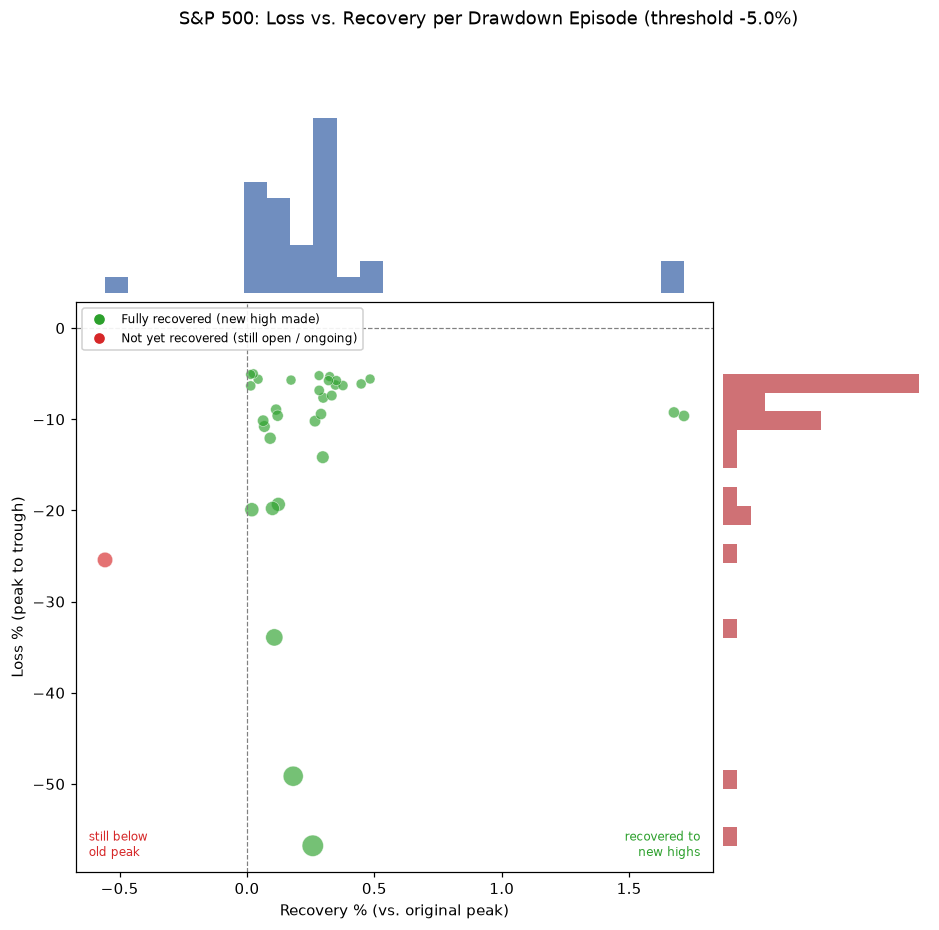

In [6]:
fig = plt.figure(figsize=(10, 9))
grid = fig.add_gridspec(4, 4, hspace=0.05, wspace=0.05)

ax_scatter = fig.add_subplot(grid[1:4, 0:3])
ax_histx = fig.add_subplot(grid[0, 0:3], sharex=ax_scatter)
ax_histy = fig.add_subplot(grid[1:4, 3], sharey=ax_scatter)

colors = episodes['recovered'].map({True: '#2ca02c', False: '#d62728'})
sizes = 25 + episodes['loss_pct'].abs() * 3

ax_scatter.axhline(0, color='grey', lw=0.8, ls='--')
ax_scatter.axvline(0, color='grey', lw=0.8, ls='--')
ax_scatter.scatter(episodes['recovery_pct'], episodes['loss_pct'],
                    c=colors, s=sizes, alpha=0.65, edgecolor='white', linewidth=0.4)

ax_scatter.set_xlabel('Recovery % (vs. original peak)')
ax_scatter.set_ylabel('Loss % (peak to trough)')

# quadrant shading / labels
ax_scatter.text(0.98, 0.02, 'recovered to\nnew highs', transform=ax_scatter.transAxes,
                 ha='right', va='bottom', fontsize=8, color='#2ca02c')
ax_scatter.text(0.02, 0.02, 'still below\nold peak', transform=ax_scatter.transAxes,
                 ha='left', va='bottom', fontsize=8, color='#d62728')

ax_histx.hist(episodes['recovery_pct'], bins=25, color='#4c72b0', alpha=0.8)
ax_histx.axis('off')

ax_histy.hist(episodes['loss_pct'], bins=25, orientation='horizontal', color='#c44e52', alpha=0.8)
ax_histy.axis('off')

from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], marker='o', color='w', label='Fully recovered (new high made)',
           markerfacecolor='#2ca02c', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Not yet recovered (still open / ongoing)',
           markerfacecolor='#d62728', markersize=8),
]
ax_scatter.legend(handles=legend_elems, loc='upper left', fontsize=8, framealpha=0.9)

fig.suptitle(f'{TICKER_LABEL}: Loss vs. Recovery per Drawdown Episode '
             f'(threshold {DRAWDOWN_THRESHOLD}%)', y=0.98)
plt.show()

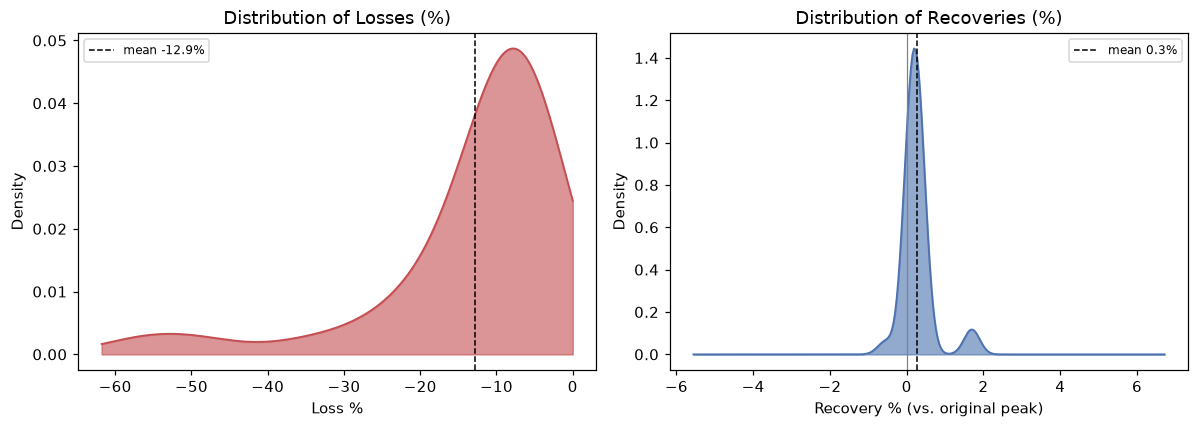

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))


loss_data = episodes['loss_pct'].dropna()
x_loss = np.linspace(loss_data.min() - 5, loss_data.max() + 5, 300)
kde_loss = gaussian_kde(loss_data)
axes[0].fill_between(x_loss, kde_loss(x_loss), color='#c44e52', alpha=0.6)
axes[0].plot(x_loss, kde_loss(x_loss), color='#c44e52', lw=1.2)
axes[0].axvline(loss_data.mean(), color='black', ls='--', lw=1,
                 label=f"mean {loss_data.mean():.1f}%")
axes[0].set_title('Distribution of Losses (%)')
axes[0].set_xlabel('Loss %')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)


rec_data = episodes['recovery_pct'].dropna()
x_rec = np.linspace(rec_data.min() - 5, rec_data.max() + 5, 300)
kde_rec = gaussian_kde(rec_data)
axes[1].fill_between(x_rec, kde_rec(x_rec), color='#4c72b0', alpha=0.6)
axes[1].plot(x_rec, kde_rec(x_rec), color='#4c72b0', lw=1.2)
axes[1].axvline(rec_data.mean(), color='black', ls='--', lw=1,
                 label=f"mean {rec_data.mean():.1f}%")
axes[1].axvline(0, color='grey', lw=0.8)
axes[1].set_title('Distribution of Recoveries (%)')
axes[1].set_xlabel('Recovery % (vs. original peak)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

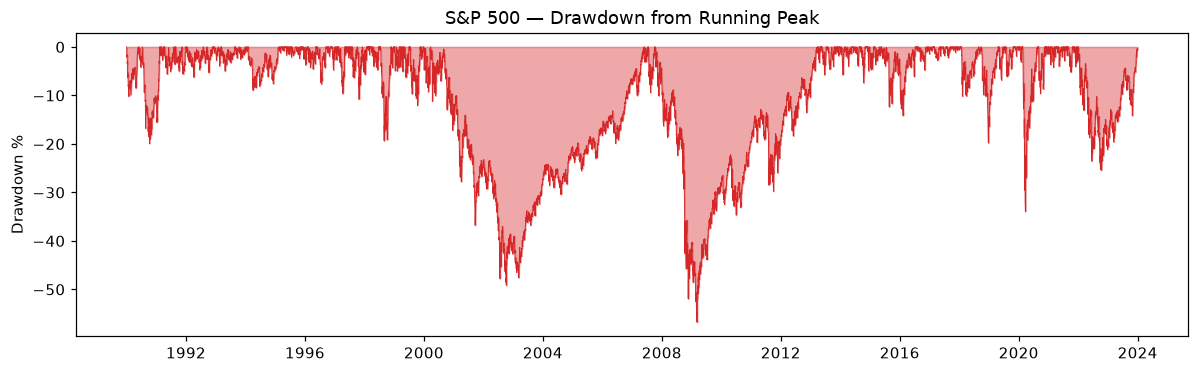

In [8]:
running_max = df['Close'].cummax()
drawdown_series = (df['Close'] - running_max) / running_max * 100

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.fill_between(df['Date'], drawdown_series, 0, color='#d62728', alpha=0.4)
ax.plot(df['Date'], drawdown_series, color='#d62728', lw=0.6)
ax.set_title(f'{TICKER_LABEL} — Drawdown from Running Peak')
ax.set_ylabel('Drawdown %')
plt.tight_layout()
plt.show()

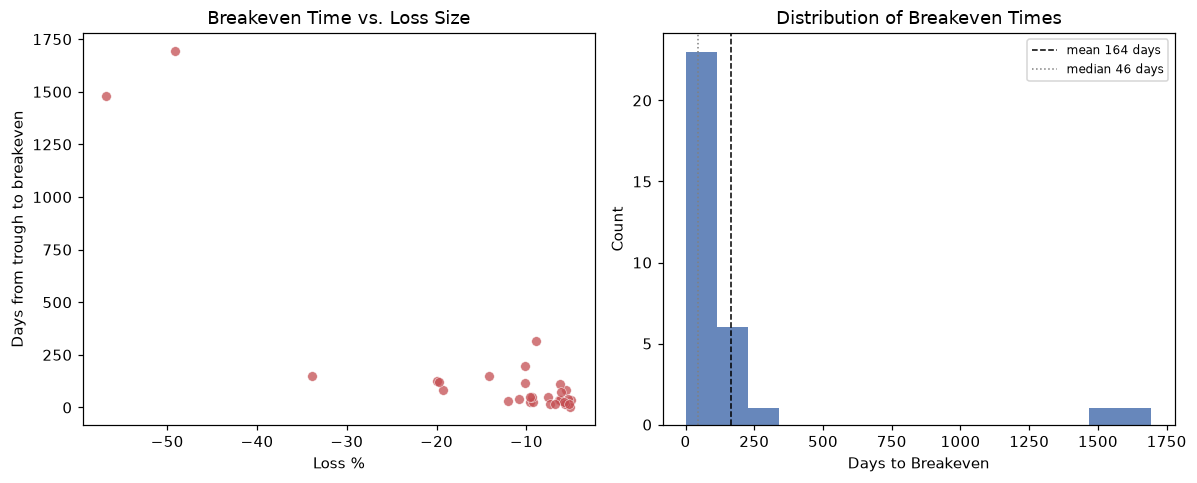

In [9]:
recovered = episodes[episodes['recovered']].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))


axes[0].scatter(recovered['loss_pct'], recovered['days_to_recover'],
                 color='#c44e52', s=40, alpha=0.75, edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Loss %')
axes[0].set_ylabel('Days from trough to breakeven')
axes[0].set_title('Breakeven Time vs. Loss Size')


axes[1].hist(recovered['days_to_recover'], bins=15, color='#4c72b0', alpha=0.85)
axes[1].axvline(recovered['days_to_recover'].mean(), color='black', ls='--', lw=1,
                 label=f"mean {recovered['days_to_recover'].mean():.0f} days")
axes[1].axvline(recovered['days_to_recover'].median(), color='grey', ls=':', lw=1,
                 label=f"median {recovered['days_to_recover'].median():.0f} days")
axes[1].set_xlabel('Days to Breakeven')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Breakeven Times')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()



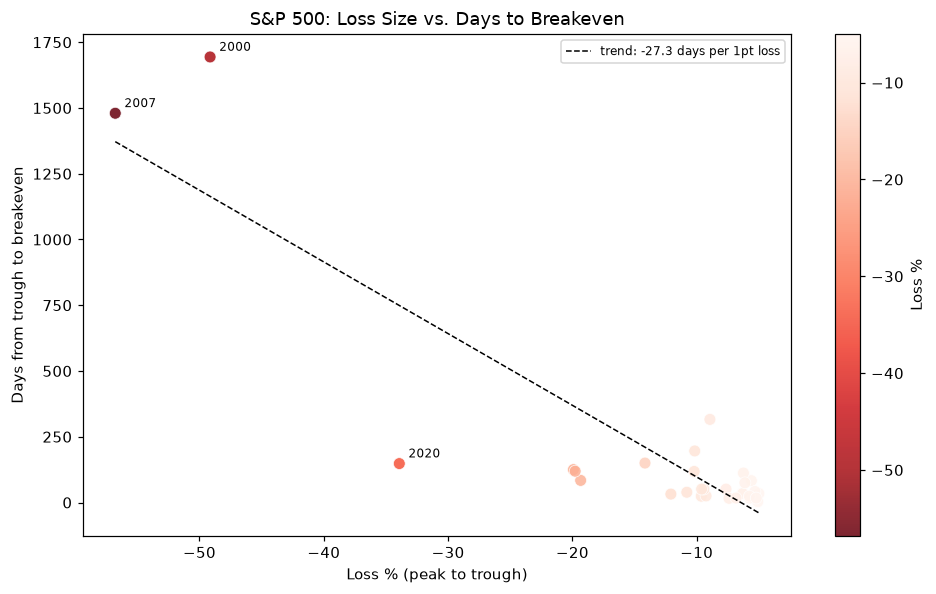

Correlation (loss %, days to recover): -0.88


In [10]:
from numpy.polynomial import polynomial as P

recovered = episodes[episodes['recovered']].copy()

fig, ax = plt.subplots(figsize=(9, 5.5))

sc = ax.scatter(recovered['loss_pct'], recovered['days_to_recover'],
                 c=recovered['loss_pct'], cmap='Reds_r', s=60,
                 alpha=0.85, edgecolor='white', linewidth=0.5)


coeffs = np.polyfit(recovered['loss_pct'], recovered['days_to_recover'], 1)
x_line = np.linspace(recovered['loss_pct'].min(), recovered['loss_pct'].max(), 100)
y_line = np.polyval(coeffs, x_line)
ax.plot(x_line, y_line, color='black', ls='--', lw=1,
        label=f'trend: {coeffs[0]:.1f} days per 1pt loss')

ax.set_xlabel('Loss % (peak to trough)')
ax.set_ylabel('Days from trough to breakeven')
ax.set_title(f'{TICKER_LABEL}: Loss Size vs. Days to Breakeven')
ax.legend(fontsize=8)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Loss %')


for _, row in recovered.nsmallest(3, 'loss_pct').iterrows():
    ax.annotate(f"{row['peak_date'].year}", (row['loss_pct'], row['days_to_recover']),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

plt.tight_layout()
plt.show()

corr = recovered['loss_pct'].corr(recovered['days_to_recover'])
print(f"Correlation (loss %, days to recover): {corr:.2f}")

# Conclusion

The distribution is barbelled 

- For Loss < 20 recovery is within a year 

- for extreme loss It takes minimum 4 - 5 years to breakeven

